# Task 4: Sales Prediction
Predicting sales revenue based on advertising spend across TV, Radio, and Newspaper.

Dataset Preview:
           TV      Radio  Newspaper      Sales
0  112.362036  32.101582  10.312387  17.611313
1  285.214292   4.206998  90.255291  20.918920
2  219.598183   8.081436  50.525237  19.324547
3  179.597545  44.927709  82.645747  22.596647
4   46.805592  30.321453  32.004960  13.999672
Shape: (200, 4)


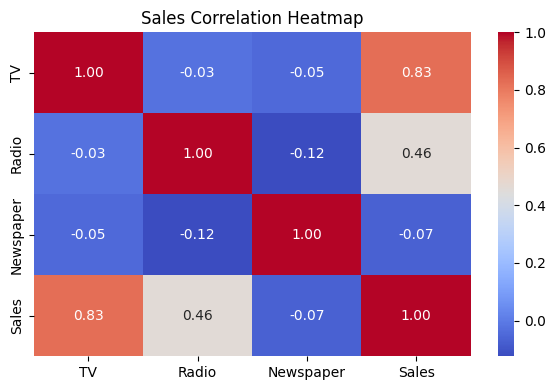


R2 Score: 0.9428
RMSE: 1.2464

Coefficients:
  TV: 0.0493
  Radio: 0.1741
  Newspaper: 0.0067


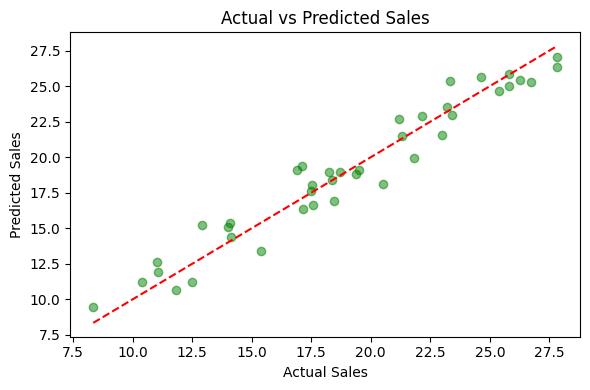

Done!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Synthetic data
np.random.seed(42)
n_sales = 200
df_sales = pd.DataFrame({
    'TV': np.random.uniform(0, 300, n_sales),
    'Radio': np.random.uniform(0, 50, n_sales),
    'Newspaper': np.random.uniform(0, 100, n_sales)
})
df_sales['Sales'] = (7 + 0.05 * df_sales['TV'] +
                     0.18 * df_sales['Radio'] +
                     0.001 * df_sales['Newspaper'] +
                     np.random.normal(0, 1.5, n_sales))

print('Dataset Preview:')
print(df_sales.head())
print(f'Shape: {df_sales.shape}')

# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_sales.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Sales Correlation Heatmap')
plt.tight_layout()
plt.show()

# Model
X = df_sales[['TV', 'Radio', 'Newspaper']]
y = df_sales['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'\nR2 Score: {r2_score(y_test, y_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print('\nCoefficients:')
for feat, coef in zip(['TV', 'Radio', 'Newspaper'], model.coef_):
    print(f'  {feat}: {coef:.4f}')

# Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.tight_layout()
plt.show()
print('Done!')
